In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CodeAlpha Internship - Task 3

# Data Visualization

## Project: Sales Data Analysis and Visualization

### Objective

The objective of this project is to analyze sales data
and create meaningful visualizations to identify trends,
patterns, relationships and business insights.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [4]:
import pandas as pd
df= pd.read_csv("/sales_data.csv")

In [5]:
df.head()

,Order_ID,Order_Date,Category,Sub_Category,Region,City,Quantity,Discount,Sales,Profit
0,ORD-0001,2025-03-13,Furniture,Chairs,East,Patna,5,0.10,1377.07,169.48
1,ORD-0002,2025-05-30,Technology,Printers,West,Ahmedabad,5,0.05,2065.62,382.64
2,ORD-0003,2025-06-10,Office Supplies,Binders,West,Mumbai,6,0.15,120.00,23.16
3,ORD-0004,2025-02-20,Technology,Laptops,East,Bhubaneswar,7,0.15,3815.29,489.16
4,ORD-0005,2025-11-25,Technology,Accessories,East,Kolkata,7,0.05,915.54,72.42


In [6]:
df.shape

(1000, 10)

In [7]:
df.columns

Index(['Order_ID', 'Order_Date', 'Category', 'Sub_Category', 'Region', 'City',
       'Quantity', 'Discount', 'Sales', 'Profit'],
      dtype='object')

In [8]:
df.info

<bound method DataFrame.info of      Order_ID  Order_Date         Category Sub_Category Region         City  \
0    ORD-0001  2025-03-13        Furniture       Chairs   East        Patna   
1    ORD-0002  2025-05-30       Technology     Printers   West    Ahmedabad   
2    ORD-0003  2025-06-10  Office Supplies      Binders   West       Mumbai   
3    ORD-0004  2025-02-20       Technology      Laptops   East  Bhubaneswar   
4    ORD-0005  2025-11-25       Technology  Accessories   East      Kolkata   
..        ...         ...              ...          ...    ...          ...   
995  ORD-0996  2025-12-25  Office Supplies      Binders   East        Patna   
996  ORD-0997  2025-07-18       Technology       Phones   East        Patna   
997  ORD-0998  2025-06-18       Technology     Printers  South    Bengaluru   
998  ORD-0999  2025-02-16  Office Supplies       Labels   East        Patna   
999  ORD-1000  2025-08-22  Office Supplies       Labels  North        Delhi   

     Quantity  Discount    Sales  Profit  
0           5      0.10  1377.07  169.48  
1           5      0.05  2065.62  382.64  
2           6      0.15   120.00   23.16  
3           7      0.15  3815.29  489.16  
4           7      0.05   915.54   72.42  
..        ...       ...      ...     ...  
995         6      0.30   854.32  111.54  
996         3      0.05  1943.06  177.85  
997         4      0.10  1486.47  209.86  
998         9      0.15  1059.09   83.55  
999         4      0.00   551.75  133.01  

[1000 rows x 10 columns]>

In [9]:
df.describe()

,Quantity,Discount,Sales,Profit
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,4.947000,0.131700,1428.73863,167.752680
std,2.629278,0.096744,1276.39977,189.018743
min,1.000000,0.000000,29.19000,-92.940000
25%,3.000000,0.050000,477.34000,42.450000
50%,5.000000,0.150000,1014.75000,100.060000
75%,7.000000,0.200000,1999.49750,230.850000
max,9.000000,0.300000,7963.38000,1214.870000


In [10]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Category,0
Sub_Category,0
Region,0
City,0
Quantity,0
Discount,0
Sales,0
Profit,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(1000, 10)

In [14]:
df=df.copy()

In [15]:
df.dtypes

,0
Order_ID,object
Order_Date,object
Category,object
Sub_Category,object
Region,object
City,object
Quantity,int64
Discount,float64
Sales,float64
Profit,float64


In [16]:
df[['Quantity','Discount','Sales','Profit']].describe()

,Quantity,Discount,Sales,Profit
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,4.947000,0.131700,1428.73863,167.752680
std,2.629278,0.096744,1276.39977,189.018743
min,1.000000,0.000000,29.19000,-92.940000
25%,3.000000,0.050000,477.34000,42.450000
50%,5.000000,0.150000,1014.75000,100.060000
75%,7.000000,0.200000,1999.49750,230.850000
max,9.000000,0.300000,7963.38000,1214.870000


In [17]:
df['Order_Date']=pd.to_datetime(df['Order_Date'])

In [18]:
df['Year']=df['Order_Date'].dt.year

In [19]:
df['Month']=df['Order_Date'].dt.month

In [20]:
df['Month_Year']=df['Order_Date'].dt.to_period('M').astype(str)

In [21]:
df[['Order_Date', 'Year','Month','Month_Year']].head()

,Order_Date,Year,Month,Month_Year
0,2025-03-13,2025,3,2025-03
1,2025-05-30,2025,5,2025-05
2,2025-06-10,2025,6,2025-06
3,2025-02-20,2025,2,2025-02
4,2025-11-25,2025,11,2025-11


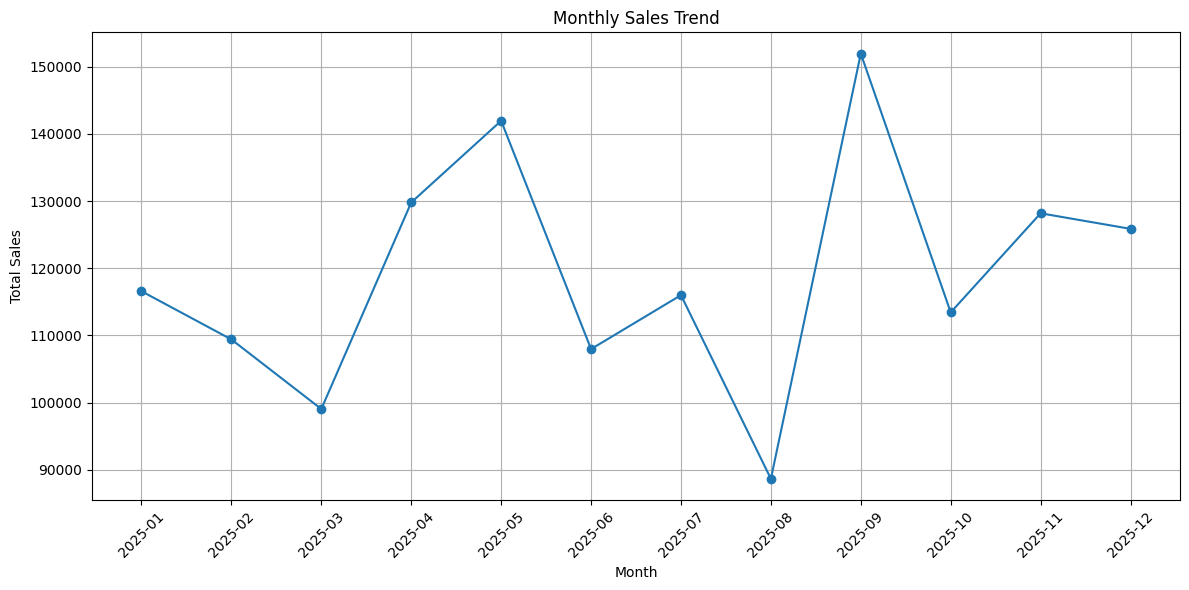

In [22]:
monthly_sales = (
    df.groupby('Month_Year')['Sales']
    .sum()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [23]:
plt.savefig('monthly_sales.png', dpi=300)

<Figure size 640x480 with 0 Axes>

In [24]:
plt.tight_layout()
plt.savefig('monthly_sales.png',dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

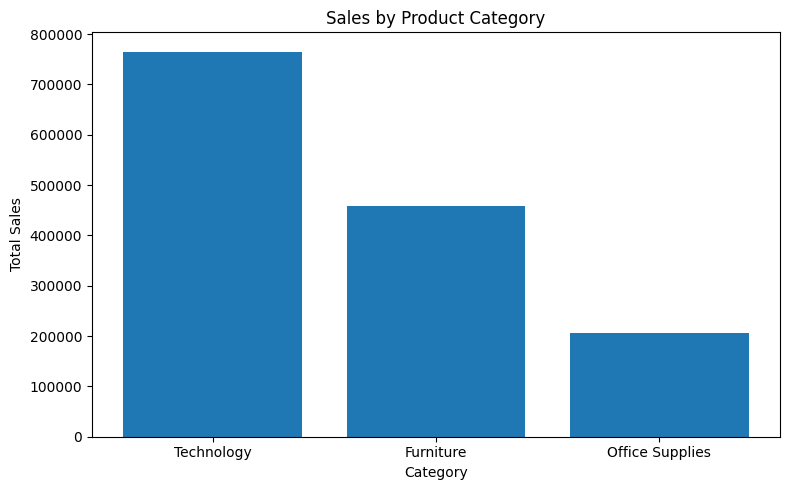

In [25]:
category_sales = (
    df.groupby('Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title('Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

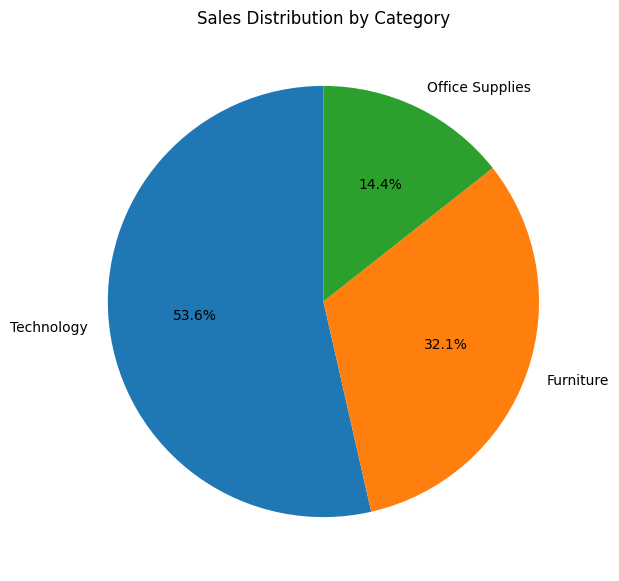

In [26]:
plt.figure(figsize=(7, 7))

plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Sales Distribution by Category')

plt.show()

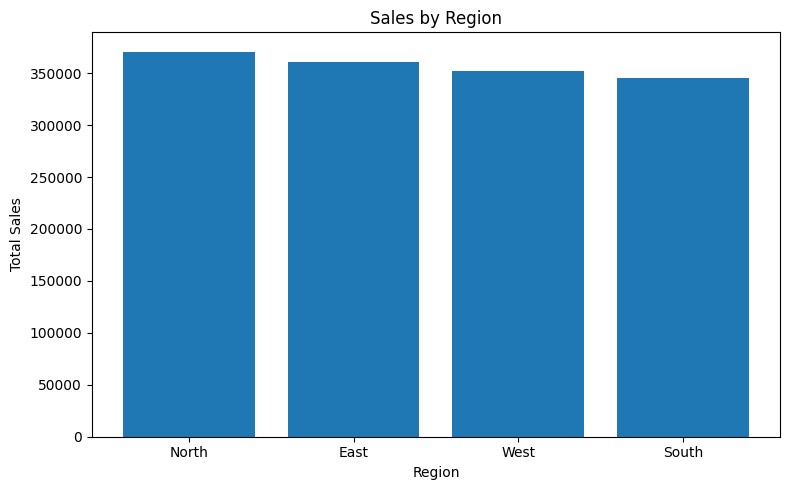

In [27]:
region_sales = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    region_sales.index,
    region_sales.values
)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

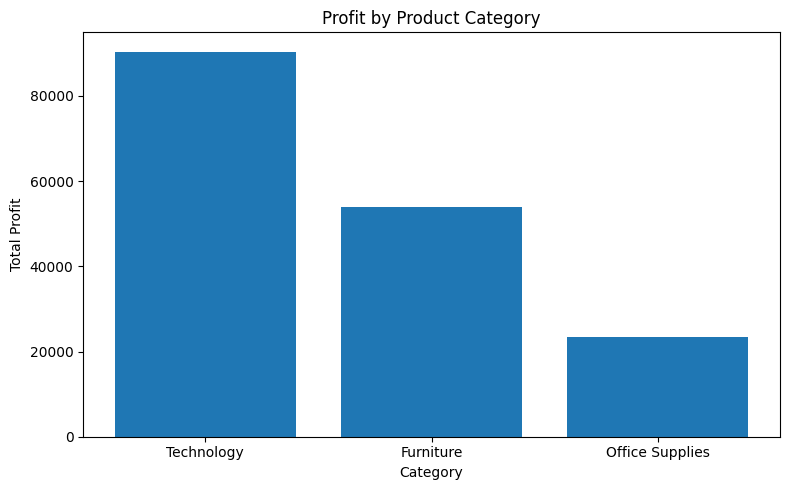

In [28]:
category_profit = (
    df.groupby('Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    category_profit.index,
    category_profit.values
)

plt.title('Profit by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')

plt.tight_layout()
plt.show()

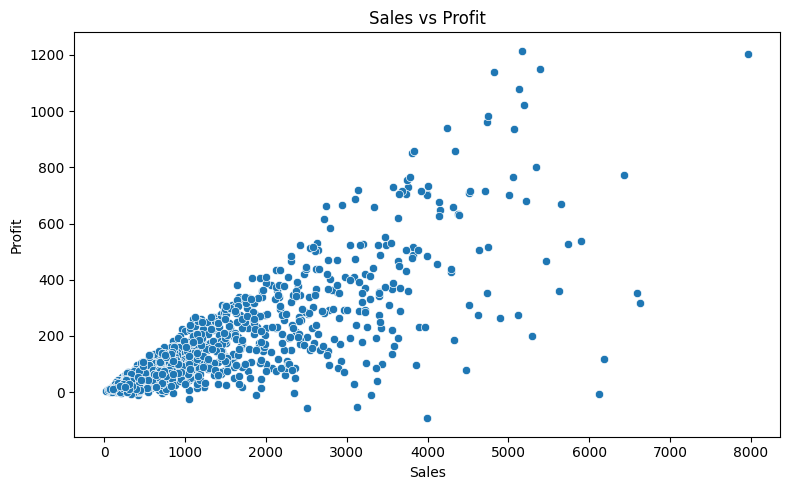

In [29]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit'
)

plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()

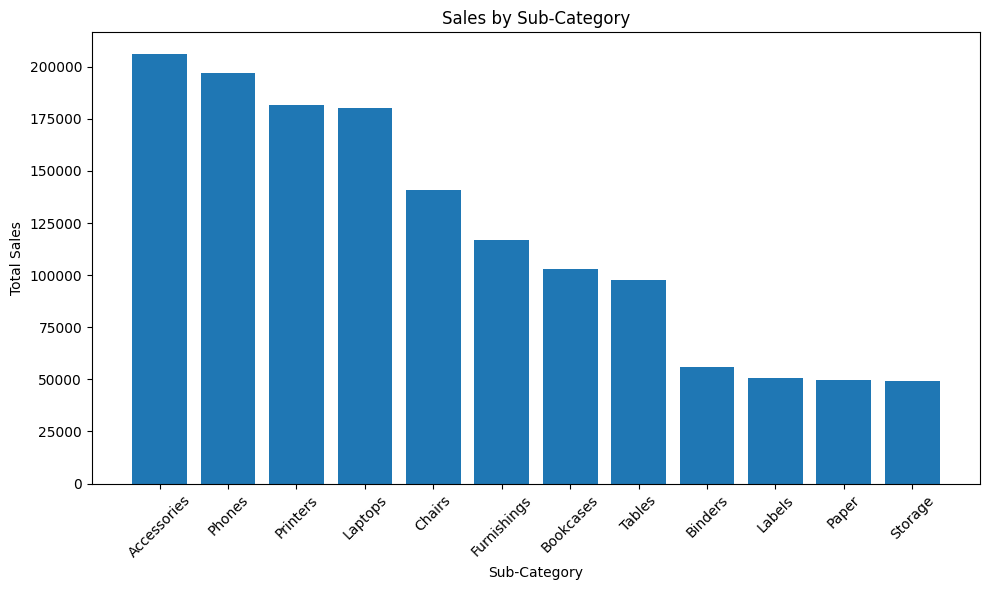

In [30]:
subcategory_sales = (
    df.groupby('Sub_Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    subcategory_sales.index,
    subcategory_sales.values
)

plt.title('Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

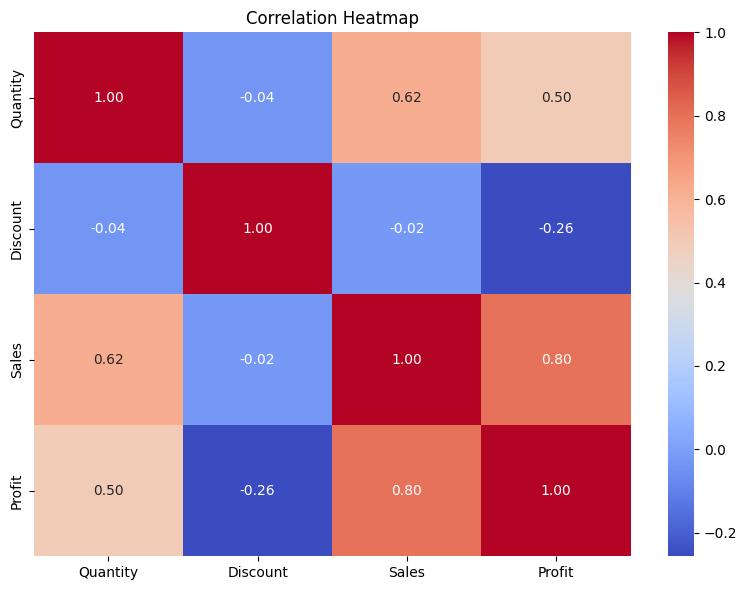

In [31]:
numeric_data = df[
    ['Quantity', 'Discount', 'Sales', 'Profit']
]

correlation = numeric_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# Key Insights

## 1. Overall Sales

The analysis shows the overall sales performance across the
different months of the year.

## 2. Category Performance

Technology generated the highest total sales among the
three product categories.

## 3. Regional Performance

The North region recorded the highest total sales among
the four regions.

## 4. Profitability

Technology generated the highest total profit among the
product categories.

## 5. Sub-Category Performance

Accessories recorded the highest sales among the
different sub-categories.

## 6. Sales and Profit Relationship

The scatter plot shows the relationship between sales
and profit across individual orders.

## 7. Correlation

The correlation heatmap highlights relationships between
quantity, discount, sales and profit.

# Conclusion

This project analyzed a sales dataset using Python and
data visualization techniques.

Pandas was used for data loading, cleaning and analysis,
while Matplotlib and Seaborn were used to create meaningful
visualizations.

The analysis identified sales trends, category performance,
regional performance, profitability and relationships
between numerical variables.

The project demonstrates how raw data can be transformed
into meaningful visual insights that can support
data-driven decision-making.

# Project Objective

The objective of this project is to transform raw sales
data into meaningful visualizations and identify trends,
patterns and insights that can support business
decision-making.

In [33]:
import os
os.makedirs("charts",exist_ok=True)